In [ ]:
# CELL 1: Setup & Mount
print("🚀 Setting up environment...")

import os
import gc
import shutil
from google.colab import drive

# Mount Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("✓ Drive already mounted")

# Install dependencies
!pip install -q rasterio tqdm

import numpy as np
import rasterio
from rasterio.windows import Window
from pathlib import Path
from tqdm import tqdm

print("✅ Setup complete!")

🚀 Setting up environment...
Mounted at /content/drive
✅ Setup complete!


In [ ]:
# CELL 2: RAM-Safe Parallel Extraction (Chunked Reading)
print("\n" + "="*70)
print(f"EXTRACTING {PATCH_SIZE}x{PATCH_SIZE} TEST PAIRS (RAM SAFE)")
print("="*70)

# We will load 1024x1024 chunks into RAM at a time.
# This keeps memory < 300MB per CPU core, completely preventing Colab crashes.
CHUNK_SIZE = 1024

def process_tile_for_testing_safe(tile_file):
    saved_count = 0
    local_tile_path = Path("/content") / tile_file.name

    try:
        shutil.copy(tile_file, local_tile_path)

        with rasterio.open(local_tile_path) as tile_src, rasterio.open(local_labels_path) as lbl_src:
            if tile_src.count != 64:
                return 0

            w, h = tile_src.width, tile_src.height

            # Read the image in medium-sized 1024x1024 chunks
            for y_chunk in range(0, h, CHUNK_SIZE):
                for x_chunk in range(0, w, CHUNK_SIZE):

                    # Define the window for this chunk
                    window_w = min(CHUNK_SIZE, w - x_chunk)
                    window_h = min(CHUNK_SIZE, h - y_chunk)

                    if window_w < PATCH_SIZE or window_h < PATCH_SIZE:
                        continue # Skip edge chunks that are too small

                    window = rasterio.windows.Window(x_chunk, y_chunk, window_w, window_h)

                    # 1. READ CHUNK INTO RAM (Fast, Low Memory)
                    chunk_img = tile_src.read(window=window)

                    # 2. GET CORRESPONDING LABEL CHUNK
                    chunk_bounds = rasterio.windows.bounds(window, tile_src.transform)
                    lbl_window = rasterio.windows.from_bounds(
                        *chunk_bounds, transform=lbl_src.transform
                    ).round_lengths().round_offsets()

                    chunk_mask = lbl_src.read(1, window=lbl_window)

                    # Sync dimensions just in case of sub-pixel rounding
                    min_h = min(chunk_img.shape[1], chunk_mask.shape[0])
                    min_w = min(chunk_img.shape[2], chunk_mask.shape[1])
                    chunk_img = chunk_img[:, :min_h, :min_w]
                    chunk_mask = chunk_mask[:min_h, :min_w]

                    # 3. SLICE THE CHUNK IN RAM
                    for y in range(0, min_h - PATCH_SIZE + 1, STRIDE):
                        for x in range(0, min_w - PATCH_SIZE + 1, STRIDE):

                            img_patch = chunk_img[:, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                            mask_patch = chunk_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

                            # NaN Check
                            if np.isnan(img_patch).sum() > (img_patch.size * MAX_NAN_RATIO):
                                continue

                            img_patch = np.nan_to_num(img_patch, nan=0.0).astype(np.float16)
                            mask_patch = mask_patch.astype(np.uint8)

                            # Calculate global coordinates for the filename
                            global_y = y_chunk + y
                            global_x = x_chunk + x

                            file_id = f"{tile_file.stem}_y{global_y}_x{global_x}"
                            np.save(images_dir / f"{file_id}.npy", img_patch)
                            np.save(masks_dir / f"{file_id}.npy", mask_patch)

                            saved_count += 1

                    # Explicitly free memory after each chunk
                    del chunk_img, chunk_mask

    except Exception as e:
        print(f"Error on {tile_file.name}: {e}")

    finally:
        if local_tile_path.exists():
            local_tile_path.unlink()
        gc.collect()

    return saved_count

# Multiprocessing Execution
total_saved = 0
workers = min(os.cpu_count(), 4) # Cap workers at 4 just to be extra safe with RAM overhead

print(f"Starting chunked RAM-safe extraction using {workers} CPU cores...\n")

with ProcessPoolExecutor(max_workers=workers) as executor:
    futures = {executor.submit(process_tile_for_testing_safe, tf): tf for tf in tile_files}

    for future in tqdm(as_completed(futures), total=len(tile_files), desc="Processing Tiles"):
        total_saved += future.result()

print(f"\n✅ RAM-Safe Testing Extraction Complete!")
print(f"Total testing pairs (Image + Label) saved: {total_saved:,}")

CONFIGURATION: U-NET DATASET (LOCAL SSD OPTIMIZED)
Labels: /content/drive/MyDrive/bow_river_wetlands_10m_final.tif
Embeddings: /content/drive/MyDrive/EarthEngine
Local Output: /content/UNet_Wetland_Dataset
Patch Size: 128x128 (Stride: 128)

✓ Found 88 embedding tiles
  Training Tiles: 70
  Validation Tiles: 18


In [ ]:
# CELL 2.5: Spatial Metadata Verification
import rasterio

print("\n" + "="*70)
print("VERIFYING SPATIAL ALIGNMENT (METADATA)")
print("="*70)

# Get the first available embedding tile to check against the labels
sample_embed_file = list(embeddings_dir.glob("*embed*.tif"))[0]

with rasterio.open(labels_file) as lbl_src, rasterio.open(sample_embed_file) as emb_src:
    print(f"Labels CRS:      {lbl_src.crs}")
    print(f"Embeddings CRS:  {emb_src.crs}")

    print(f"\nLabels Resolution:     {lbl_src.res}")
    print(f"Embeddings Resolution: {emb_src.res}")

    lbl_bounds = lbl_src.bounds
    emb_bounds = emb_src.bounds
    print(f"\nLabels Bounds:     (Left: {lbl_bounds.left:.2f}, Bottom: {lbl_bounds.bottom:.2f}, Right: {lbl_bounds.right:.2f}, Top: {lbl_bounds.top:.2f})")
    print(f"Embeddings Bounds: (Left: {emb_bounds.left:.2f}, Bottom: {emb_bounds.bottom:.2f}, Right: {emb_bounds.right:.2f}, Top: {emb_bounds.top:.2f})")

    # Automated Assertions
    if lbl_src.crs != emb_src.crs:
        print("\n⚠️ CRITICAL WARNING: CRS mismatch. Your masks will not align with your images.")
    elif lbl_src.res != emb_src.res:
        print("\n⚠️ CRITICAL WARNING: Resolution mismatch. Pixels represent different physical sizes.")
    else:
        print("\n✅ Metadata aligns! Proceed to extraction.")


VERIFYING SPATIAL ALIGNMENT (METADATA)
Labels CRS:      EPSG:32612
Embeddings CRS:  EPSG:32612

Labels Resolution:     (10.0, 10.0)
Embeddings Resolution: (10.0, 10.0)

Labels Bounds:     (Left: 186241.45, Bottom: 5529292.70, Right: 500521.45, Top: 5735362.70)
Embeddings Bounds: (Left: 173610.00, Bottom: 5714400.00, Right: 204330.00, Top: 5745120.00)

✅ Metadata aligns! Proceed to extraction.


In [ ]:
# CELL 3: Drive-Safe Coordinate-Based Patch Extraction (UPDATED)
import shutil
import gc
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm
from pathlib import Path
import os
import random

print("\n" + "="*70)
print(f"EXTRACTING {PATCH_SIZE}x{PATCH_SIZE} WITH OVERLAP AND BACKGROUND SAMPLING")
print("="*70)

# --- NEW HYPERPARAMETERS ---
STRIDE = 64              # 50% overlap for spatial context
BG_KEEP_PROB = 0.15      # Keep 15% of pure background patches
MAX_NAN_RATIO = 0.10     # Max 10% NaN pixels allowed per patch

def extract_unet_patches_safely(tile_set, split_name):
    img_dir = dirs[f'{split_name}_images']
    mask_dir = dirs[f'{split_name}_masks']
    saved_count = 0
    bg_count = 0

    local_labels = Path("/content/local_labels.tif")
    if not local_labels.exists():
        print("Copying labels to local disk...")
        shutil.copy(labels_file, local_labels)

    with rasterio.open(local_labels) as lbl_src:
        for tile_file in tqdm(tile_set, desc=f"Processing {split_name.capitalize()} Tiles"):

            _, _, free_bytes = shutil.disk_usage("/")
            if free_bytes < (2 * 1024 * 1024 * 1024):
                print("\n⚠️ CRITICAL: Colab disk is almost full! Stopping early.")
                break

            local_tile_path = Path("/content") / tile_file.name

            try:
                shutil.copy(tile_file, local_tile_path)

                with rasterio.open(local_tile_path) as tile_src:
                    if tile_src.count != 64:
                        continue

                    h, w = tile_src.height, tile_src.width

                    # Sliding window with updated STRIDE
                    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
                        for x in range(0, w - PATCH_SIZE + 1, STRIDE):

                            local_window = Window(x, y, PATCH_SIZE, PATCH_SIZE)
                            img_patch = tile_src.read(window=local_window)

                            # 1. NaN Handling: Impute instead of aggressively dropping
                            total_pixels = img_patch.size
                            nan_mask = np.isnan(img_patch)

                            if nan_mask.sum() > (total_pixels * MAX_NAN_RATIO):
                                continue # Drop only if heavily corrupted

                            # Replace minor NaNs with 0.0 (imputation)
                            img_patch = np.nan_to_num(img_patch, nan=0.0)

                            patch_transform = tile_src.window_transform(local_window)
                            left, bottom, right, top = rasterio.transform.array_bounds(
                                PATCH_SIZE, PATCH_SIZE, patch_transform
                            )

                            lbl_window = rasterio.windows.from_bounds(
                                left, bottom, right, top, transform=lbl_src.transform
                            )

                            lbl_window = lbl_window.round_lengths().round_offsets()
                            mask_patch = lbl_src.read(1, window=lbl_window)

                            if mask_patch.shape != (PATCH_SIZE, PATCH_SIZE):
                                continue

                            # 2. Smart Background Sampling
                            is_wetland = np.sum(mask_patch > 0) >= (PATCH_SIZE * PATCH_SIZE * 0.05)

                            if not is_wetland:
                                # It's a background patch. Keep it based on probability.
                                if random.random() > BG_KEEP_PROB:
                                    continue
                                bg_count += 1

                            img_patch_f16 = img_patch.astype(np.float16)
                            mask_patch_u8 = mask_patch.astype(np.uint8)

                            file_id = f"{tile_file.stem}_y{y}_x{x}"
                            np.save(img_dir / f"{file_id}.npy", img_patch_f16)
                            np.save(mask_dir / f"{file_id}.npy", mask_patch_u8)

                            saved_count += 1

            except Exception as e:
                print(f"\nError processing {tile_file.name}: {e}")

            finally:
                if local_tile_path.exists():
                    local_tile_path.unlink()

            gc.collect()

    print(f"  -> Background patches included: {bg_count}")
    return saved_count

train_saved = extract_unet_patches_safely(train_tiles, 'train')
val_saved = extract_unet_patches_safely(val_tiles, 'val')

print(f"\n✅ Extraction Complete!")
print(f"Train pairs saved: {train_saved:,}")
print(f"Val pairs saved:   {val_saved:,}")


EXTRACTING 128x128 WITH OVERLAP AND BACKGROUND SAMPLING
Copying labels to local disk...


Processing Train Tiles: 100%|██████████| 70/70 [2:07:11<00:00, 109.02s/it]


  -> Background patches included: 14236


Processing Val Tiles: 100%|██████████| 18/18 [33:58<00:00, 113.24s/it]

  -> Background patches included: 3649

✅ Extraction Complete!
Train pairs saved: 35,979
Val pairs saved:   12,723



VISUAL ALIGNMENT CHECK
Sample File: bow_river_embeddings_2020_CORRECTED-0000003072-0000024576_y2624_x64.npy
Unique classes in this mask: [0]


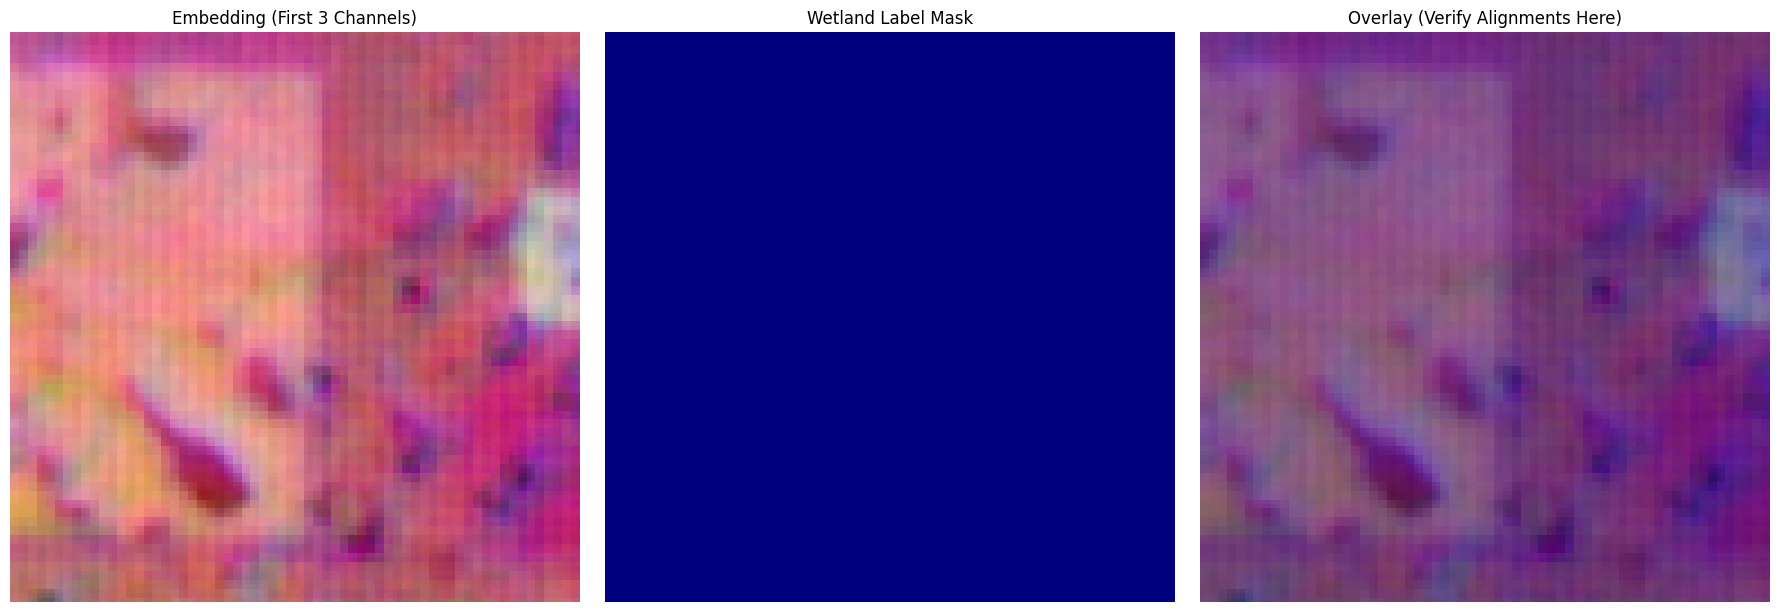

In [ ]:
# CELL 4: Visual Verification & Overlay
import random
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*70)
print("VISUAL ALIGNMENT CHECK")
print("="*70)

train_images = list(dirs['train_images'].glob('*.npy'))

if len(train_images) == 0:
    print("⚠️ No patches were saved. Check overlap or filtering logic.")
else:
    # Pick a random saved pair
    sample_img_path = random.choice(train_images)
    sample_mask_path = dirs['train_masks'] / sample_img_path.name

    img = np.load(sample_img_path).astype(np.float32)
    mask = np.load(sample_mask_path)

    print(f"Sample File: {sample_img_path.name}")
    print(f"Unique classes in this mask: {np.unique(mask)}")

    # Take the first 3 channels for visualization (assuming they hold the most variance)
    # Transpose from (C, H, W) to (H, W, C) for Matplotlib
    vis_img = img[0:3, :, :].transpose(1, 2, 0)

    # Normalize image to [0, 1] range so it renders properly in matplotlib
    vis_img = (vis_img - np.nanmin(vis_img)) / (np.nanmax(vis_img) - np.nanmin(vis_img) + 1e-8)

    # Plotting
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    ax1.imshow(vis_img)
    ax1.set_title("Embedding (First 3 Channels)")
    ax1.axis('off')

    ax2.imshow(mask, cmap='jet', interpolation='nearest')
    ax2.set_title("Wetland Label Mask")
    ax2.axis('off')

    # Overlay
    ax3.imshow(vis_img)
    ax3.imshow(mask, cmap='jet', alpha=0.4, interpolation='nearest')
    ax3.set_title("Overlay (Verify Alignments Here)")
    ax3.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# CELL 5: Compress and Transfer (UPDATED FOR V2)
print("\n" + "="*70)
print("COMPRESSING AND TRANSFERRING TO DRIVE (V2)")
print("="*70)

local_archive_base = "/content/UNet_Wetland_Dataset_Archive"

# 🛑 UPDATED: Changed destination file name to prevent overwriting your original dataset
drive_destination = "/content/drive/MyDrive/UNet_Wetland_Dataset_v2.zip"

print("Zipping local dataset... (This is fast on the local SSD)")
shutil.make_archive(
    base_name=local_archive_base,
    format="zip",
    root_dir=local_output_base
)

print("Moving .zip to Google Drive... (This takes a moment)")
# Overwrite if v2 already exists, but safely protects the original v1
if os.path.exists(drive_destination):
    os.remove(drive_destination)

shutil.move(f"{local_archive_base}.zip", drive_destination)

print(f"\n🎉 Success! Final v2 dataset safely stored at:")
print(f"-> {drive_destination}")


COMPRESSING AND TRANSFERRING TO DRIVE (V2)
Zipping local dataset... (This is fast on the local SSD)
Moving .zip to Google Drive... (This takes a moment)

🎉 Success! Final v2 dataset safely stored at:
-> /content/drive/MyDrive/UNet_Wetland_Dataset_v2.zip


VISUAL ALIGNMENT VERIFICATION
Visualizing Patch: bow_river_embeddings_2020_CORRECTED-0000012288-0000006144_y1088_x896.npy


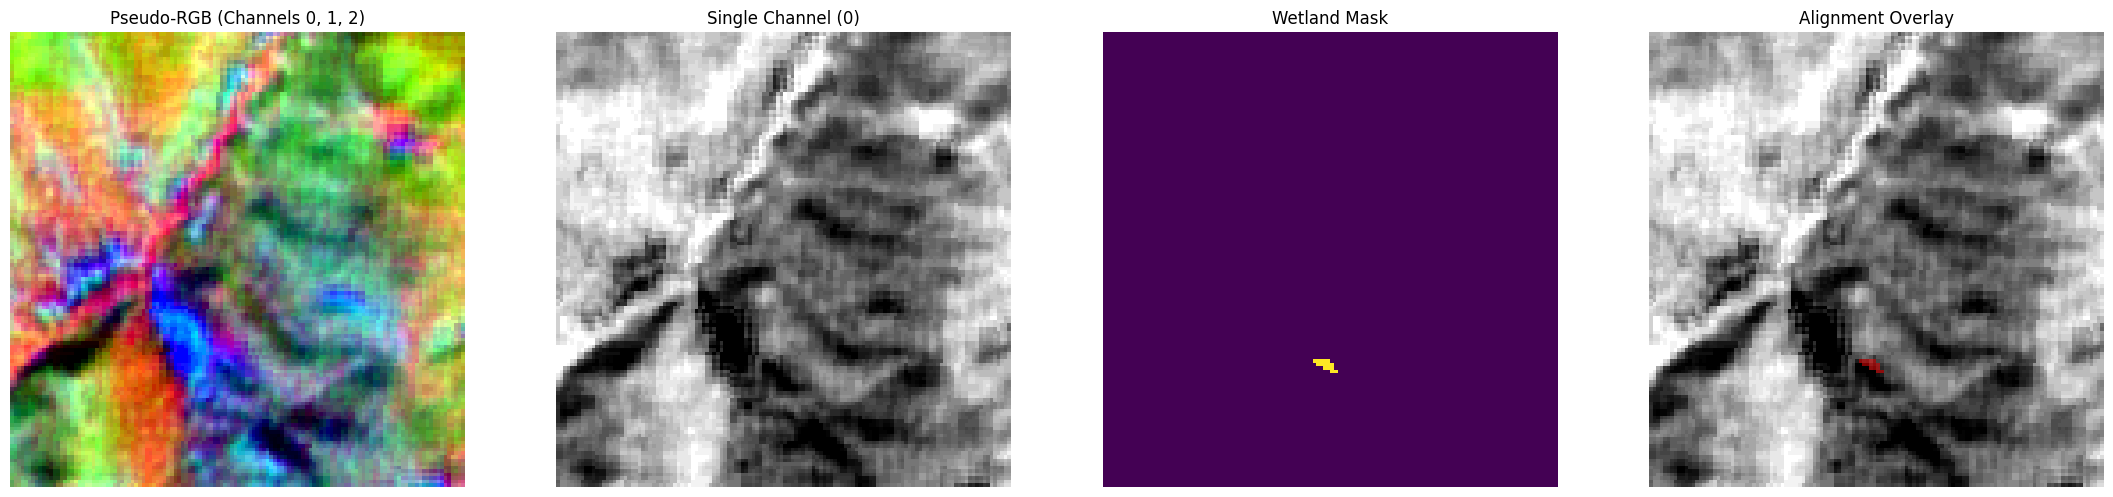

In [ ]:
# CELL 6: Visual Spatial Verification
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

print("="*70)
print("VISUAL ALIGNMENT VERIFICATION")
print("="*70)

# Re-define paths in case this is run in a fresh session
train_images_dir = Path("/content/UNet_Wetland_Dataset/train/images")
train_masks_dir = Path("/content/UNet_Wetland_Dataset/train/masks")

train_images = list(train_images_dir.glob('*.npy'))

if not train_images:
    print("⚠️ No training images found! Ensure you have extracted the patches in Cell 3.")
else:
    # 1. Select a random sample
    sample_img_path = random.choice(train_images)
    sample_mask_path = train_masks_dir / sample_img_path.name

    # 2. Load data
    img = np.load(sample_img_path).astype(np.float32)  # Cast to float32 for Matplotlib
    mask = np.load(sample_mask_path)    # Shape: (128, 128), uint8

    print(f"Visualizing Patch: {sample_img_path.name}")

    # --- Preprocessing for Visualization ---

    # Extract a single channel to serve as our grayscale basemap (e.g., Channel 0)
    # You can change this index if you know a specific channel highlights wetlands well
    channel_idx = 0
    img_single_channel = img[channel_idx, :, :]

    # Robust Normalization (2nd to 98th percentile) to handle extreme values in EO data
    p2, p98 = np.percentile(img_single_channel, (2, 98))
    img_vis = np.clip((img_single_channel - p2) / (p98 - p2 + 1e-8), 0, 1)

    # Create a Pseudo-RGB composite using the first 3 channels
    rgb_channels = img[0:3, :, :]
    rgb_vis = np.transpose(rgb_channels, (1, 2, 0)) # Transpose to (H, W, C) for plotting

    for i in range(3):
        p2_c, p98_c = np.percentile(rgb_vis[..., i], (2, 98))
        rgb_vis[..., i] = np.clip((rgb_vis[..., i] - p2_c) / (p98_c - p2_c + 1e-8), 0, 1)

    # --- Plotting ---
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    # Plot 1: Pseudo-RGB
    axes[0].imshow(rgb_vis)
    axes[0].set_title("Pseudo-RGB (Channels 0, 1, 2)")
    axes[0].axis('off')

    # Plot 2: Single Channel Grayscale
    axes[1].imshow(img_vis, cmap='gray')
    axes[1].set_title(f"Single Channel ({channel_idx})")
    axes[1].axis('off')

    # Plot 3: The Mask / Label
    # Using 'viridis' or 'jet' helps distinguish class boundaries
    axes[2].imshow(mask, cmap='viridis')
    axes[2].set_title("Wetland Mask")
    axes[2].axis('off')

    # Plot 4: Overlay
    axes[3].imshow(img_vis, cmap='gray')
    # Mask out the background (assuming 0 is background) so only the wetlands overlay
    mask_overlay = np.ma.masked_where(mask == 0, mask)
    axes[3].imshow(mask_overlay, cmap='autumn', alpha=0.5)
    axes[3].set_title("Alignment Overlay")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()